# Training KongNet from Scratch on CoNIC


## About this notebook

This notebook demonstrates the new structured-dense training workflow in `tiatoolbox.models.training` using a KongNet model trained from scratch on the CoNIC patch dataset.

Workflow used here:
1. Load the PNG patches and paired annotation stores created from CoNIC `images.npy` and `labels.npy`.
2. Build a full 3-channel supervision target for each CoNIC class head: `mask`, `boundary`, and `centroid`.
3. Instantiate KongNet and derive a `StructuredDenseTask` with `build_kongnet_training_task()`.
4. Train for a few epochs on a small demo subset.
5. Run inference on a few validation patches and visualise the learned mask, boundary, centroid, and peak outputs.

This is intentionally a lightweight demonstration. Challenge-grade KongNet training would use the full dataset, more augmentation, larger batches, and substantially more epochs.


## Optional: Colab setup


In [ ]:
%%bash
python -m pip install --quiet --upgrade pip
python -m pip install --quiet tiatoolbox


If you are using Colab and ran the install cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [1]:
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tiatoolbox.models.architecture.kongnet import KongNet
from tiatoolbox.models.engine.io_config import IOSegmentorConfig
from tiatoolbox.models.training import (
    BoundaryTargetBuilder,
    CompositeTargetBuilder,
    GaussianHeatmapTargetBuilder,
    MaskTargetBuilder,
    PatchAnnotationDataset,
    StackedTargetBuilder,
    Trainer,
    TrainerConfig,
    TrainingArtifactManifest,
    make_dataloaders,
    build_kongnet_training_task,
    get_annotation_augmentation,
)

rng = np.random.default_rng(7)
torch.manual_seed(7)

SUPERVISION_CHANNELS = ("mask", "boundary", "centroid")

device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.dpi"] = 140
print(f"Using device: {device}")

def load_rgb_image(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def stack_head_channel_maps(
    target_dict: dict[str, torch.Tensor],
    ordered_keys: list[str],
    channel_index: int,
) -> np.ndarray:
    return np.stack(
        [target_dict[key][channel_index].cpu().numpy() for key in ordered_keys],
        axis=-1,
    )

def extract_kongnet_head_channel_maps(
    model: KongNet,
    logits: torch.Tensor,
    ordered_keys: list[str],
) -> dict[str, np.ndarray]:
    probabilities = torch.sigmoid(logits).detach().cpu()
    head_specs = {spec.name: spec for spec in model.training_output_spec}
    channel_maps = {channel_name: [] for channel_name in SUPERVISION_CHANNELS}

    for head_key in ordered_keys:
        head_spec = head_specs[head_key]
        head_probabilities = probabilities[:, head_spec.channel_slice, :, :]
        for channel_index, channel_name in enumerate(SUPERVISION_CHANNELS):
            channel_maps[channel_name].append(head_probabilities[:, channel_index].numpy())

    return {
        channel_name: np.stack(head_maps, axis=-1)
        for channel_name, head_maps in channel_maps.items()
    }


|2026-04-13|21:15:49.627| [WARNING] /home/mark-eastwood/miniforge3/envs/comfyui/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Using device: cuda


## Locate the converted CoNIC data

This notebook assumes you already ran `examples/prepare_conic_training_data.py`, which should have created:
- `images_png/` containing one PNG patch per CoNIC sample
- `annotation_stores/` containing one `.db` store per PNG patch


In [ ]:
data_root = Path("/media/mark-eastwood/Work/Data/Conic")
images_dir = data_root / "images_png"
stores_dir = data_root / "annotation_stores"

if not images_dir.exists() or not stores_dir.exists():
    raise FileNotFoundError(
        "Expected `images_png/` and `annotation_stores/` inside the CoNIC directory. "
        "Run `examples/prepare_conic_training_data.py` first."
    )


## Define a compact KongNet supervision recipe

KongNet has 6 heads on CoNIC, with 3 output channels per head in the pretrained architecture. In this example we supervise all 3 channels of every head:

- `mask`: dense per-class foreground map
- `boundary`: dense contour map
- `centroid`: dense Gaussian detection heatmap

That gives a substantially more faithful KongNet-style training recipe while still using the generic structured-dense training additions from the recent PRs.


In [ ]:
conic_class_dict = {
    0: "Neutrophil",
    1: "Epithelial",
    2: "Lymphocyte",
    3: "Plasma",
    4: "Eosinophil",
    5: "Connective",
}
ordered_head_keys = [label.lower() for label in conic_class_dict.values()]

target_builder = CompositeTargetBuilder(
    {
        label.lower(): StackedTargetBuilder(
            {
                "mask": MaskTargetBuilder(
                    class_mapping=None,
                    default_label=0,
                ),
                "boundary": BoundaryTargetBuilder(line_width=1),
                "centroid": GaussianHeatmapTargetBuilder(sigma=2.0),
            },
            where=f'props["class"] == "{label}"',
        )
        for label in conic_class_dict.values()
    }
)

paired_dataset = PatchAnnotationDataset.from_dirs(
    patch_dir=images_dir,
    annotation_store_dir=stores_dir,
    target_builder=target_builder,
)
print(f"Found {len(paired_dataset)} PNG/store pairs.")

train_augmentation = get_annotation_augmentation(
    "light",
    target_builder=target_builder,
)

demo_train_size = 4096
demo_val_size = 512
demo_size = demo_train_size + demo_val_size
if demo_size > len(paired_dataset):
    raise ValueError(
        f"Requested {demo_size} demo samples, but only found {len(paired_dataset)} pairs."
    )

demo_indices = rng.permutation(len(paired_dataset))[:demo_size]
train_indices = demo_indices[:demo_train_size]
val_indices = demo_indices[demo_train_size:]

print(f"Demo train pairs: {len(train_indices)}")
print(f"Demo val pairs: {len(val_indices)}")


### Validation split note

> **Avoid leakage:** the compact demo below randomly splits patch files for speed. For publishable experiments, derive the split from slide/case/patient metadata first, then build `train_indices` and `val_indices` from those groups. Patch-level random splits can overestimate validation performance when near-duplicate patches or patches from the same patient appear in both sets.


## Build datasets and preview one target sample


In [ ]:
train_base_dataset = PatchAnnotationDataset.from_dirs(
    patch_dir=images_dir,
    annotation_store_dir=stores_dir,
    target_builder=target_builder,
    pair_transform=train_augmentation.pair_transform,
    image_transform=KongNet.preproc,
)
train_dataset = torch.utils.data.Subset(train_base_dataset, train_indices.tolist())

val_base_dataset = PatchAnnotationDataset.from_dirs(
    patch_dir=images_dir,
    annotation_store_dir=stores_dir,
    target_builder=target_builder,
    image_transform=KongNet.preproc,
)
val_dataset = torch.utils.data.Subset(val_base_dataset, val_indices.tolist())

preview_image_path = val_base_dataset.patch_inputs[val_indices[0]]
preview_raw = load_rgb_image(preview_image_path)
preview_item = val_dataset[0]
preview_mask_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 0)
preview_boundary_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 1)
preview_centroid_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(preview_raw)
axes[0].set_title("Raw CoNIC patch")
axes[1].imshow(np.max(preview_mask_maps, axis=-1), cmap="gray")
axes[1].set_title("Max class masks")
axes[2].imshow(np.max(preview_boundary_maps, axis=-1), cmap="gray")
axes[2].set_title("Max class boundaries")
axes[3].imshow(np.max(preview_centroid_maps, axis=-1), cmap="magma")
axes[3].set_title("Max centroid heatmaps")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


## Instantiate KongNet and derive the structured dense task

We keep KongNet's native 3-channel-per-head layout and supervise each head as a single stacked dense target.


In [5]:
model = KongNet(
    num_heads=6,
    num_channels_per_head=[3, 3, 3, 3, 3, 3],
    target_channels=[2, 5, 8, 11, 14, 17],
    min_distance=5,
    threshold_abs=0.35,
    class_dict=conic_class_dict,
)

task = build_kongnet_training_task(
    model,
    target_selection="full_head",
)

pd.DataFrame(
    [
        {
            "head": spec.name,
            "display_name": spec.display_name,
            "channel_slice": str(spec.channel_slice),
            "target_channels": list(spec.target_channels),
            "target_offsets": list(spec.target_channel_offsets),
        }
        for spec in model.training_output_spec
    ]
)


,head,display_name,channel_slice,target_channels,target_offsets
0,neutrophil,Neutrophil,"slice(0, 3, None)",[2],[2]
1,epithelial,Epithelial,"slice(3, 6, None)",[5],[2]
2,lymphocyte,Lymphocyte,"slice(6, 9, None)",[8],[2]
3,plasma,Plasma,"slice(9, 12, None)",[11],[2]
4,eosinophil,Eosinophil,"slice(12, 15, None)",[14],[2]
5,connective,Connective,"slice(15, 18, None)",[17],[2]


## Data loaders and a trainer run

The settings below are intentionally conservative so the notebook remains runnable on modest hardware. Increase the subset sizes, batch size, and epoch count for a more serious training run.


In [ ]:
batch_size = 8 if device == "cuda" else 1

train_loader, val_loader = make_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=batch_size,
    num_workers=4,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

train_output_dir = Path("examples/tmp/15-kongnet-conic-training")
if train_output_dir.exists():
    shutil.rmtree(train_output_dir)

artifact_ioconfig = IOSegmentorConfig(
    input_resolutions=[{"units": "baseline", "resolution": 1.0}],
    output_resolutions=[{"units": "baseline", "resolution": 1.0}],
    patch_input_shape=preview_raw.shape[:2],
    patch_output_shape=preview_raw.shape[:2],
    stride_shape=preview_raw.shape[:2],
)

training_artifact = TrainingArtifactManifest.from_model(
    model,
    task_type="multi_task_segmentation",
    model_constructor={
        "num_heads": 6,
        "num_channels_per_head": [3, 3, 3, 3, 3, 3],
        "target_channels": [2, 5, 8, 11, 14, 17],
        "min_distance": 5,
        "threshold_abs": 0.35,
    },
    class_dict=conic_class_dict,
    preprocessing={"name": "KongNet.preproc"},
    postprocessing={"name": "KongNet.postproc"},
    ioconfig=artifact_ioconfig,
    engine="MultiTaskSegmentor",
    metadata={"ordered_head_keys": ordered_head_keys},
)

trainer = Trainer(
    model=model,
    task=task,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=30,
        seed=7,
        output_dir=train_output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
    artifact_manifest=training_artifact,
)

history = trainer.fit()
history_df = pd.DataFrame(history)
history_df.tail()


artifact = TrainingArtifactManifest.load(train_output_dir / "training_artifact.json")
engine_setup = artifact.to_engine_setup("MultiTaskSegmentor")
print("Saved artifact weights:", artifact.weights)
print("Engine constructor kwargs:", engine_setup.constructor_kwargs)
print("Engine run kwargs:", sorted(engine_setup.run_kwargs))


|2026-04-13|21:16:25.265| [INFO] Epoch 1/30 | monitor `val_loss`=6.556454 | best=6.556454
|2026-04-13|21:16:52.014| [INFO] Epoch 2/30 | monitor `val_loss`=4.233336 | best=4.233336
|2026-04-13|21:17:19.037| [INFO] Epoch 3/30 | monitor `val_loss`=3.866016 | best=3.866016
|2026-04-13|21:17:45.432| [INFO] Epoch 4/30 | monitor `val_loss`=3.817515 | best=3.817515
|2026-04-13|21:18:12.014| [INFO] Epoch 5/30 | monitor `val_loss`=3.436715 | best=3.436715
|2026-04-13|21:18:39.862| [INFO] Epoch 6/30 | monitor `val_loss`=3.329371 | best=3.329371
|2026-04-13|21:19:07.536| [INFO] Epoch 7/30 | monitor `val_loss`=3.280278 | best=3.280278
|2026-04-13|21:19:34.899| [INFO] Epoch 8/30 | monitor `val_loss`=3.177664 | best=3.177664
|2026-04-13|21:20:01.730| [INFO] Epoch 9/30 | monitor `val_loss`=3.143014 | best=3.143014
|2026-04-13|21:20:29.354| [INFO] Epoch 10/30 | monitor `val_loss`=2.976217 | best=2.976217
|2026-04-13|21:20:56.586| [INFO] Epoch 11/30 | monitor `val_loss`=2.911385 | best=2.911385
|2026-04

,epoch,train_loss,train_neutrophil_loss,train_neutrophil_dice,train_neutrophil_iou,train_epithelial_loss,train_epithelial_dice,train_epithelial_iou,train_lymphocyte_loss,train_lymphocyte_dice,...,val_lymphocyte_iou,val_plasma_loss,val_plasma_dice,val_plasma_iou,val_eosinophil_loss,val_eosinophil_dice,val_eosinophil_iou,val_connective_loss,val_connective_dice,val_connective_iou
25,26.0,1.640844,0.300609,0.473900,0.335132,0.264589,0.499399,0.353679,0.301383,0.474777,...,0.338391,0.233970,0.469798,0.339098,0.293899,0.510875,0.366163,0.256305,0.483980,0.344867
26,27.0,1.581885,0.289617,0.469665,0.332984,0.254926,0.499210,0.353816,0.291030,0.465609,...,0.343661,0.237752,0.468768,0.338066,0.300751,0.515528,0.366375,0.257036,0.485942,0.348262
27,28.0,1.525565,0.279174,0.467523,0.332061,0.245724,0.500637,0.355082,0.281291,0.460827,...,0.304215,0.224074,0.440666,0.316003,0.271609,0.484096,0.345359,0.240409,0.429509,0.309598
28,29.0,1.469745,0.269334,0.459202,0.327454,0.236967,0.498803,0.354128,0.270998,0.451446,...,0.321207,0.212224,0.446560,0.324062,0.258199,0.495419,0.356143,0.230847,0.442412,0.322698
29,30.0,1.418010,0.259442,0.460924,0.329379,0.228628,0.500674,0.355843,0.261777,0.448982,...,0.304909,0.208889,0.456203,0.328666,0.254158,0.514855,0.370086,0.224514,0.425250,0.310912


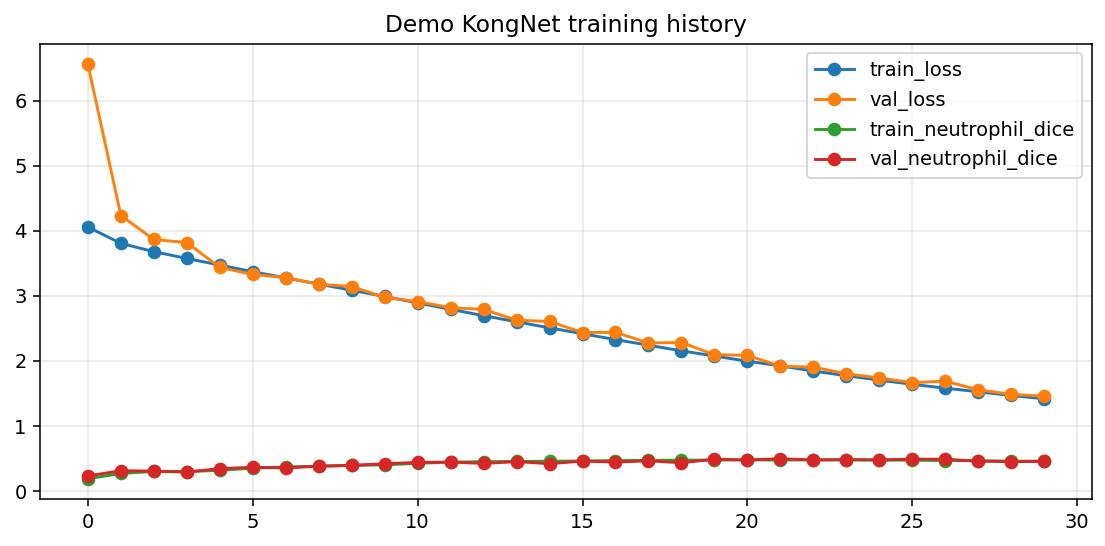

In [7]:
metric_columns = ["train_loss", "val_loss"]
if "train_neutrophil_dice" in history_df:
    metric_columns.extend(["train_neutrophil_dice", "val_neutrophil_dice"])

history_df[metric_columns].plot(marker="o", figsize=(8, 4))
plt.title("Demo KongNet training history")
plt.grid(alpha=0.3)
plt.tight_layout()


## Inference on a few validation patches

We run the newly trained model on a few held-out CoNIC patches, inspect the learned mask, boundary, and centroid probability maps, and then apply KongNet's centroid post-processing to obtain per-class peak detections.


In [ ]:
model.eval()

example_count = 3
example_indices = val_indices[:example_count]
example_image_paths = [val_base_dataset.patch_inputs[index] for index in example_indices]
example_images = [load_rgb_image(image_path) for image_path in example_image_paths]
example_batch = torch.from_numpy(
    np.stack([KongNet.preproc(image).astype(np.float32) for image in example_images], axis=0)
)
example_batch_nchw = example_batch.permute(0, 3, 1, 2).to(device)

with torch.no_grad():
    example_logits = model(example_batch_nchw)

pred_component_maps = extract_kongnet_head_channel_maps(model, example_logits, ordered_head_keys)
pred_centroid_maps = pred_component_maps["centroid"]
pred_peak_maps = np.stack([model.postproc(prob_map) for prob_map in pred_centroid_maps], axis=0)
gt_centroid_maps = [
    stack_head_channel_maps(val_dataset[index]["target"], ordered_head_keys, 2)
    for index in range(example_count)
]

class_cmap = plt.cm.get_cmap("tab10", len(ordered_head_keys))
class_colours = {key: class_cmap(index) for index, key in enumerate(ordered_head_keys)}

fig, axes = plt.subplots(example_count, 6, figsize=(18, 4 * example_count))
if example_count == 1:
    axes = np.expand_dims(axes, axis=0)

for row, image in enumerate(example_images):
    peak_map = pred_peak_maps[row]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Patch {Path(example_image_paths[row]).stem}")

    axes[row, 1].imshow(np.max(gt_centroid_maps[row], axis=-1), cmap="magma")
    axes[row, 1].set_title("GT centroid heatmaps")

    axes[row, 2].imshow(np.max(pred_component_maps["mask"][row], axis=-1), cmap="gray", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Predicted mask probs")

    axes[row, 3].imshow(np.max(pred_component_maps["boundary"][row], axis=-1), cmap="gray", vmin=0.0, vmax=1.0)
    axes[row, 3].set_title("Predicted boundary probs")

    axes[row, 4].imshow(np.max(pred_component_maps["centroid"][row], axis=-1), cmap="magma", vmin=0.0, vmax=1.0)
    axes[row, 4].set_title("Predicted centroid probs")

    axes[row, 5].imshow(image)
    peak_y, peak_x, peak_c = np.where(peak_map > 0)
    if len(peak_x) > 0:
        axes[row, 5].scatter(
            peak_x,
            peak_y,
            c=[class_colours[ordered_head_keys[channel]] for channel in peak_c],
            s=10,
        )
    axes[row, 5].set_title("Post-processed peaks")

    for col in range(6):
        axes[row, col].axis("off")

plt.tight_layout()


In [ ]:
peak_count_rows = []
for row, image_path in enumerate(example_image_paths):
    row_counts = {"patch": Path(image_path).stem}
    for channel_index, head_key in enumerate(ordered_head_keys):
        row_counts[head_key] = int(pred_peak_maps[row, :, :, channel_index].sum())
    peak_count_rows.append(row_counts)

pd.DataFrame(peak_count_rows)


## Next steps

To turn this into a stronger CoNIC training recipe, the first things to scale up are:
- use the full dataset rather than the small demo subset,
- increase `max_epochs`,
- tune the relative weighting and exact target shapes for mask, boundary, and centroid supervision,
- and strengthen augmentation; stacked mask/boundary/centroid targets are augmented per channel so mask-like channels keep nearest-neighbour interpolation while centroid heatmaps stay continuous.
